In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import pandas as pd

data=pd.read_csv('wine.csv')
y=data['quality']
x=data.drop(['quality'],axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [4]:
print(x_test.shape)
print(x_train.shape)
print(y_test.shape)
print(y_train.shape)

(400, 11)
(1199, 11)
(400,)
(1199,)


In [5]:
print(y_train)

582     5
626     5
1030    7
620     5
490     6
       ..
1130    6
1294    6
860     5
1459    7
1126    6
Name: quality, Length: 1199, dtype: int64


In [6]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(32, input_dim=11,activation='relu'))
model.add(Dense(6,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
y_test=y_test-3
y_train=y_train-3
print(np.unique(y_train))

[0 1 2 3 4 5]


c:\Users\rajan\OneDrive\Desktop\internship3\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1551 - loss: 11.1564 - val_accuracy: 0.3500 - val_loss: 5.8456
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4137 - loss: 2.7471 - val_accuracy: 0.4375 - val_loss: 1.5059
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4762 - loss: 1.3036 - val_accuracy: 0.4150 - val_loss: 1.3323
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4829 - loss: 1.2335 - val_accuracy: 0.4175 - val_loss: 1.2579
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4854 - loss: 1.2151 - val_accuracy: 0.4175 - val_loss: 1.2551
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4987 - loss: 1.1987 - val_accuracy: 0.4600 - val_loss: 1.2437
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4929 - loss: 1.1906 - val_accuracy: 0.4375 - val_loss: 1.2237
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4962 - loss: 1.1840 - val_accuracy: 0.4450 - val_loss

In [8]:
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
pred =pred+3
print(pred)
model.save('wine_quality_model.h5')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


[5 5 6 6 6 6 5 6 6 6 6 6 6 6 6 6 5 5 6 5 6 6 6 6 6 6 6 5 5 6 5 6 5 6 6 5 6
 6 5 6 5 6 6 5 6 6 5 5 5 6 5 5 6 5 6 7 6 6 6 6 5 6 6 5 6 6 6 6 6 5 6 5 6 6
 6 5 6 5 5 5 5 5 6 6 6 6 5 6 5 6 6 5 6 6 5 6 5 6 6 6 6 6 6 7 6 6 6 6 5 6 6
 5 6 5 6 6 6 5 6 6 6 6 6 6 6 6 6 5 5 6 6 6 5 5 6 5 6 5 6 6 5 6 6 6 6 5 6 6
 6 5 6 6 5 6 6 6 5 6 6 6 6 6 6 5 6 6 5 6 5 5 5 6 6 5 5 5 6 5 5 5 6 6 5 6 6
 5 6 6 6 5 6 6 6 6 5 6 6 6 6 6 6 6 5 5 6 6 6 6 6 6 5 5 6 6 6 6 7 6 6 6 6 5
 6 6 6 6 6 6 6 6 5 6 6 6 6 6 6 6 6 5 6 5 6 6 6 5 6 5 6 5 5 6 6 6 6 5 6 6 6
 6 5 6 5 6 6 6 5 5 5 5 6 5 6 5 5 6 6 5 5 6 6 6 6 5 5 6 5 6 6 6 5 6 5 6 5 6
 5 6 6 6 5 6 6 6 5 5 6 6 6 6 6 6 6 6 6 6 6 5 6 6 5 5 6 6 5 5 6 5 7 6 6 6 5
 6 6 6 6 5 6 5 6 6 6 5 5 6 6 6 6 5 6 6 5 6 6 5 5 6 6 5 6 5 6 6 5 6 6 5 5 6
 5 6 6 6 6 6 5 6 6 5 5 6 5 5 6 5 6 5 6 6 6 6 6 5 6 6 6 6 6 5]


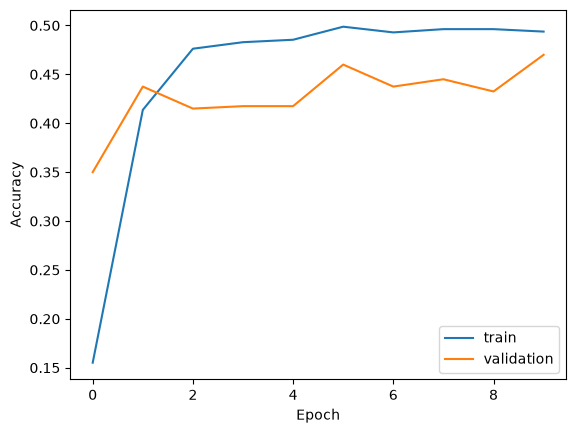

In [9]:
import matplotlib.pyplot as plt 
plt.plot(model.history.history['accuracy'],label='train')
plt.plot(model.history.history['val_accuracy'],label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()